# Binary Classification of Obesity Risk Using Behavioral and Physical Attributes

### 🔍 Project Context
This project focuses on building an end‑to‑end predictive machine learning pipeline using structured health‑related data. 

The goal is to demonstrate proficiency in problem framing, model comparison, scaling, hyperparameter optimization, and model interpretation, aligned with applied analytics and Business Intelligence practices.

The dataset used is the UCI Estimation of Obesity Levels Based on Eating Habits and Physical Condition, which contains demographic, behavioral, and physical attributes for individuals, along with labeled obesity levels.

[UCI Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)

### 🎯 Problem Definition

Binary Classification Task

We reformulate the original multi‑class obesity labels into a binary, decision‑oriented target:

0 = No Obesity 
(Normal Weight + Insufficient Weight)

1 = Obesity Risk
(Overweight + All Obesity categories)

This framing transforms the problem from academic categorization to a practical risk‑identification task, suitable for real‑world screening, intervention prioritization, or policy analysis.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [2]:
#pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544) 
  
# data (as pandas dataframes) 
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets.copy()


In [4]:
# variable information 
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables) 

                              name     role         type demographic  \
0                           Gender  Feature  Categorical      Gender   
1                              Age  Feature   Continuous         Age   
2                           Height  Feature   Continuous        None   
3                           Weight  Feature   Continuous        None   
4   family_history_with_overweight  Feature       Binary        None   
5                             FAVC  Feature       Binary        None   
6                             FCVC  Feature      Integer        None   
7                              NCP  Feature   Continuous        None   
8                             CAEC  Feature  Categorical        None   
9                            SMOKE  Feature       Binary        None   
10                            CH2O  Feature   Continuous        None   
11                             SCC  Feature       Binary        None   
12                             FAF  Feature   Continuous        

In [5]:
X.shape, y.shape

((2111, 16), (2111, 1))

The original multiclass obesity label is converted into a binary target.
Normal and underweight individuals are labeled as no risk (0),
while all overweight and obesity categories are labeled as risk (1).

In [6]:
y = y.copy()

y["obesity_risk"] = y["NObeyesdad"].apply(
    lambda x: 0 if x in ["Insufficient_Weight", "Normal_Weight"] else 1
)

In [7]:
y["obesity_risk"].value_counts(normalize=True)

obesity_risk
1    0.735197
0    0.264803
Name: proportion, dtype: float64

In [8]:
#Those two variables almost fully determine BMI
#BMI is implicitly embedded in the obesity label

X_reduced = X.drop(columns=["Weight", "Height"])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y["obesity_risk"],
    test_size=0.2,
    random_state=42,
    stratify=y["obesity_risk"]
)

In [10]:
numeric_features = X_reduced.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_reduced.select_dtypes(include=["object"]).columns


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [12]:
preprocess_no_scaling = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

preprocess_standard = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

preprocessors = {
    "No Scaling": preprocess_no_scaling,
    "StandardScaler": preprocess_standard
}


In [15]:
results = []

for prep_name, prep in preprocessors.items():
    for model_name, model in models.items():

        pipe = Pipeline([
            ("preprocess", prep),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)

        results.append({
            "Model": model_name,
            "Scaling": prep_name,
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "Accuracy": accuracy_score(y_test, y_pred)
        })

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.war

In [16]:
results_df = pd.DataFrame(results)
results_df

,Model,Scaling,ROC-AUC,Accuracy
0,Logistic Regression,No Scaling,0.921624,0.903073
1,Random Forest,No Scaling,0.978813,0.924350
2,Logistic Regression,StandardScaler,0.921681,0.900709
3,Random Forest,StandardScaler,0.978669,0.924350


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocess", preprocess_no_scaling),
    ("model", RandomForestClassifier(random_state=42))
])

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=5
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [19]:
grid_rf.best_params_

{'model__max_depth': None, 'model__n_estimators': 200}

In [20]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [21]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)


Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       112
           1       0.95      0.94      0.95       311

    accuracy                           0.92       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.92      0.92      0.92       423



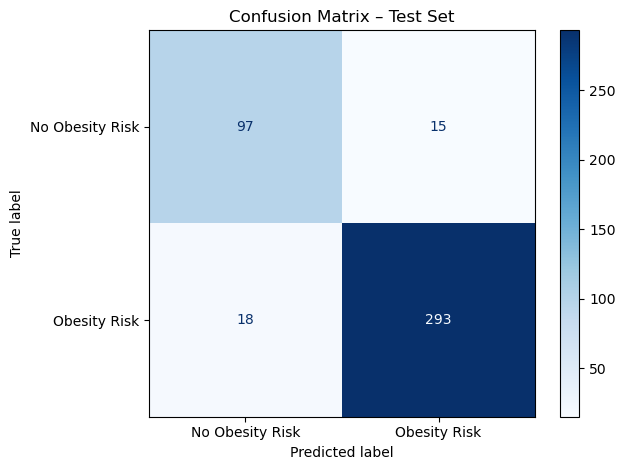

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Obesity Risk", "Obesity Risk"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.show()
